# **Odkrywanie Wiedzy i Systemy Rekomendacyjne** - *Laboratorium 4*
## Predykcja oceny z wykorzystaniem pakietu ***surprise***

In [14]:
# Instalacja pakietu surprise
!pip install --upgrade pandas==2.1.4
!pip install --upgrade numpy==1.26.4
!pip install scikit-surprise

#Wykonaj polecenie **Środowisko wykonawcze -> Uruchom ponownie sesję**.

---



In [15]:
# Wczytanie bibliotek
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from surprise import Dataset, AlgoBase, KNNBasic, SVD, accuracy
from surprise.model_selection import train_test_split, GridSearchCV, cross_validate

W ramach pakietu **surprise** możemy w prosty sposób operować na zbiorze **MovieLens**.

In [16]:
data = Dataset.load_builtin("ml-100k")

Poniższy przykład pokazuje najprostszy sposób oceny błędu dla algorytmu **SVD** z wykorzystaniem walidacji skrośnej.

In [17]:
algo = SVD()

cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=10, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 10 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Fold 6  Fold 7  Fold 8  Fold 9  Fold 10 Mean    Std     
RMSE (testset)    0.9205  0.9405  0.9308  0.9409  0.9248  0.9277  0.9230  0.9301  0.9255  0.9350  0.9299  0.0067  
MAE (testset)     0.7252  0.7354  0.7339  0.7434  0.7258  0.7314  0.7265  0.7309  0.7297  0.7402  0.7322  0.0058  
Fit time          1.00    0.96    0.94    0.92    0.98    0.94    0.96    0.94    1.05    1.30    1.00    0.10    
Test time         0.05    0.05    0.05    0.05    0.05    0.14    0.05    0.06    0.06    0.05    0.06    0.03    


{'test_rmse': array([0.92045823, 0.94051697, 0.93079572, 0.94085513, 0.92477906,
        0.92773763, 0.92304498, 0.93008336, 0.92554111, 0.93498062]),
 'test_mae': array([0.72523563, 0.73544767, 0.73385698, 0.74344391, 0.7257644 ,
        0.73139811, 0.72647229, 0.73091463, 0.72971243, 0.74019819]),
 'fit_time': (0.9971041679382324,
  0.9569549560546875,
  0.9446976184844971,
  0.9215879440307617,
  0.9821066856384277,
  0.9426605701446533,
  0.962116003036499,
  0.9429543018341064,
  1.045088768005371,
  1.2955102920532227),
 'test_time': (0.05299830436706543,
  0.04798626899719238,
  0.051026344299316406,
  0.0491175651550293,
  0.05202627182006836,
  0.1440272331237793,
  0.04999542236328125,
  0.05502915382385254,
  0.061003684997558594,
  0.052999258041381836)}

## Zadanie 1. (1 pkt)
Wykonaj walidację skrośną dla algorytmu UserKNN z kosinusową miarą podobieństwa.

In [18]:
sim_options = {
    'name': 'cosine',
    'user_based': True,
}

algo = KNNBasic(sim_options=sim_options)

cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=10, verbose=True)

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNBasic on 10 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Fold 6  Fold 7  Fold 8  Fold 9  Fold 10 Mean    Std     
RMSE (testset)    1.0148  1.0079  1.0127  1.0100  1.0193  1.0156 

{'test_rmse': array([1.01482942, 1.00793329, 1.01266376, 1.01000528, 1.01930398,
        1.01555995, 1.00514917, 1.01803182, 1.02057904, 1.01794675]),
 'test_mae': array([0.80714339, 0.79332968, 0.80052184, 0.79887918, 0.80547221,
        0.80128304, 0.79469831, 0.80216968, 0.80611838, 0.80489274]),
 'fit_time': (0.9722216129302979,
  1.10178804397583,
  0.9965131282806396,
  1.0042724609375,
  1.2960009574890137,
  1.108731985092163,
  0.9550869464874268,
  0.9966976642608643,
  0.9102027416229248,
  0.9631059169769287),
 'test_time': (1.3705637454986572,
  1.4739742279052734,
  1.3263959884643555,
  1.3150954246520996,
  1.5051681995391846,
  1.4035096168518066,
  1.3320024013519287,
  1.3913085460662842,
  1.240164041519165,
  1.2205801010131836)}



---

Oprócz walidacji skrośnej, również z pakietem **surprise** możemy dzielić dane na podzbiory trenigowy i testowy.

In [19]:
trainset, testset = train_test_split(data, test_size=0.2)

Wybrany algorytm należy wytrenować na zbiorze treningowym.

In [20]:
algo = SVD()
algo.fit(trainset)

Po czym możemy wygenerować predykcje i ocenić je zgodnie z wybraną miarą.

In [21]:
predictions = algo.test(testset)

rmse = accuracy.rmse(predictions)

RMSE: 0.9434


## Zadanie 2. (0,5 pkt)
Wyznacz wartość średniego błędu bezwzględnego dla algorytmu SVD.

In [22]:
predictions = algo.test(testset)

mae = accuracy.mae(predictions)

MAE:  0.7462


## Zadanie 3. (2 pkt)
1.   Wyznacz wartości błędów dla algorytmów ItemKNN i UserKNN z podobieństwem kosinusowym na tych samych danych, co dla algorytmu SVD.
2.   Co możesz powiedzieć o działaniu algorytmów? Czy któryś z nich jest lepszy? Dlaczego?





In [31]:
item_sim_options = {
    'name': 'cosine',
    'user_based': False,
}

item_knn = KNNBasic(sim_options=item_sim_options)
item_knn.fit(trainset)
item_predictions = item_knn.test(testset)

item_rmse = accuracy.rmse(item_predictions, verbose=False)
item_mae = accuracy.mae(item_predictions, verbose=False)

user_sim_options = {
    'name': 'cosine',
    'user_based': True,
}

user_knn = KNNBasic(sim_options=user_sim_options)
user_knn.fit(trainset)
user_predictions = user_knn.test(testset)

user_rmse = accuracy.rmse(user_predictions, verbose=False)
user_mae = accuracy.mae(user_predictions, verbose=False)

knn_results_df = pd.DataFrame({
    'algorytm': ['ItemKNN', 'UserKNN'],
    'RMSE': [item_rmse, user_rmse],
    'MAE': [item_mae, user_mae],
})

knn_results_df

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.


,algorytm,RMSE,MAE
0,ItemKNN,1.026584,0.813101
1,UserKNN,1.017563,0.807336


Dla tego podziału danych lepszy wynik uzyskał algorytm **UserKNN**. Jego błędy wyniosły RMSE = 1.017563 oraz MAE = 0.807336, natomiast dla **ItemKNN** otrzymano RMSE = 1.026584 oraz MAE = 0.813101. Obie miary są niższe dla UserKNN, więc w tym eksperymencie przewidywania oparte na podobieństwie użytkowników były dokładniejsze niż przewidywania oparte na podobieństwie filmów.

Różnica między algorytmami nie jest jednak duża, dlatego nie oznacza to, że UserKNN zawsze będzie lepszy. Wynik zależy od konkretnego zbioru danych, podziału na dane treningowe i testowe oraz dobranych parametrów. W tym przypadku można powiedzieć, że UserKNN ma niewielką przewagę, ponieważ lepiej dopasował się do ocen użytkowników w testowanym podziale.

---



Pakiet **surprise** pozwala również na automatyzację strojenia parametrów algorytmu. Do tego celu służy klasa *GridSearchCV*. Przykład automatycznego doboru parametrów dla algorytmu **UserKNN** został przedstawiony poniżej.

**Uwaga!** Kod wykonuje się ok. 4 min.


In [24]:
param_grid = {
  'k': [10, 20, 30, 40, 50], # liczba najbliższych sąsiadów
  'sim_options': {
      'name': ['cosine', 'msd', 'pearson'], # miary podobieństwa, które będą brane pod uwagę
      'user_based': [True] # czy podobieństwo użytkowników, czy itemów - w praktyce oznacza wersję UserKNN lub ItemKNN
  }
}
gs = GridSearchCV(KNNBasic, param_grid, measures=['rmse', 'mae'], cv=5) # ustawienie miar błędów oraz ilość foldów dla walidacji skrośnej
gs.fit(data)

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson si

Obiekty klasy *GridSearchCV* zawierają słownik *cv_result*, który zawiera wartości miar błędów dla wszystkich podziałów walidacji skrośnej dla wszystkich kombinacji wartości parametrów.

In [25]:
results_df = pd.DataFrame(gs.cv_results)

# spłaszczenie słownika sim_options dla łatwiejszego tworzenia wykresów
results_df['sim_metric'] = results_df['param_sim_options'].apply(lambda x: x.get('name', None) if isinstance(x, dict) else None)
results_df['user_based'] = results_df['param_sim_options'].apply(lambda x: x.get('user_based', None) if isinstance(x, dict) else None)

print(results_df.head())

   split0_test_rmse  split1_test_rmse  split2_test_rmse  split3_test_rmse  \
0          1.037018          1.048887          1.048550          1.048270   
1          0.980355          0.990391          0.989557          0.995274   
2          1.030595          1.041871          1.040545          1.042606   
3          1.019154          1.027986          1.029971          1.027653   
4          0.970010          0.977824          0.979916          0.980864   

   split4_test_rmse  mean_test_rmse  std_test_rmse  rank_test_rmse  \
0          1.039378        1.044421       0.005139              15   
1          0.987213        0.988558       0.004870               5   
2          1.043257        1.039775       0.004678              14   
3          1.020451        1.025043       0.004371              13   
4          0.972647        0.976252       0.004222               1   

   split0_test_mae  split1_test_mae  ...  rank_test_mae  mean_fit_time  \
0         0.819852         0.826146  ...  

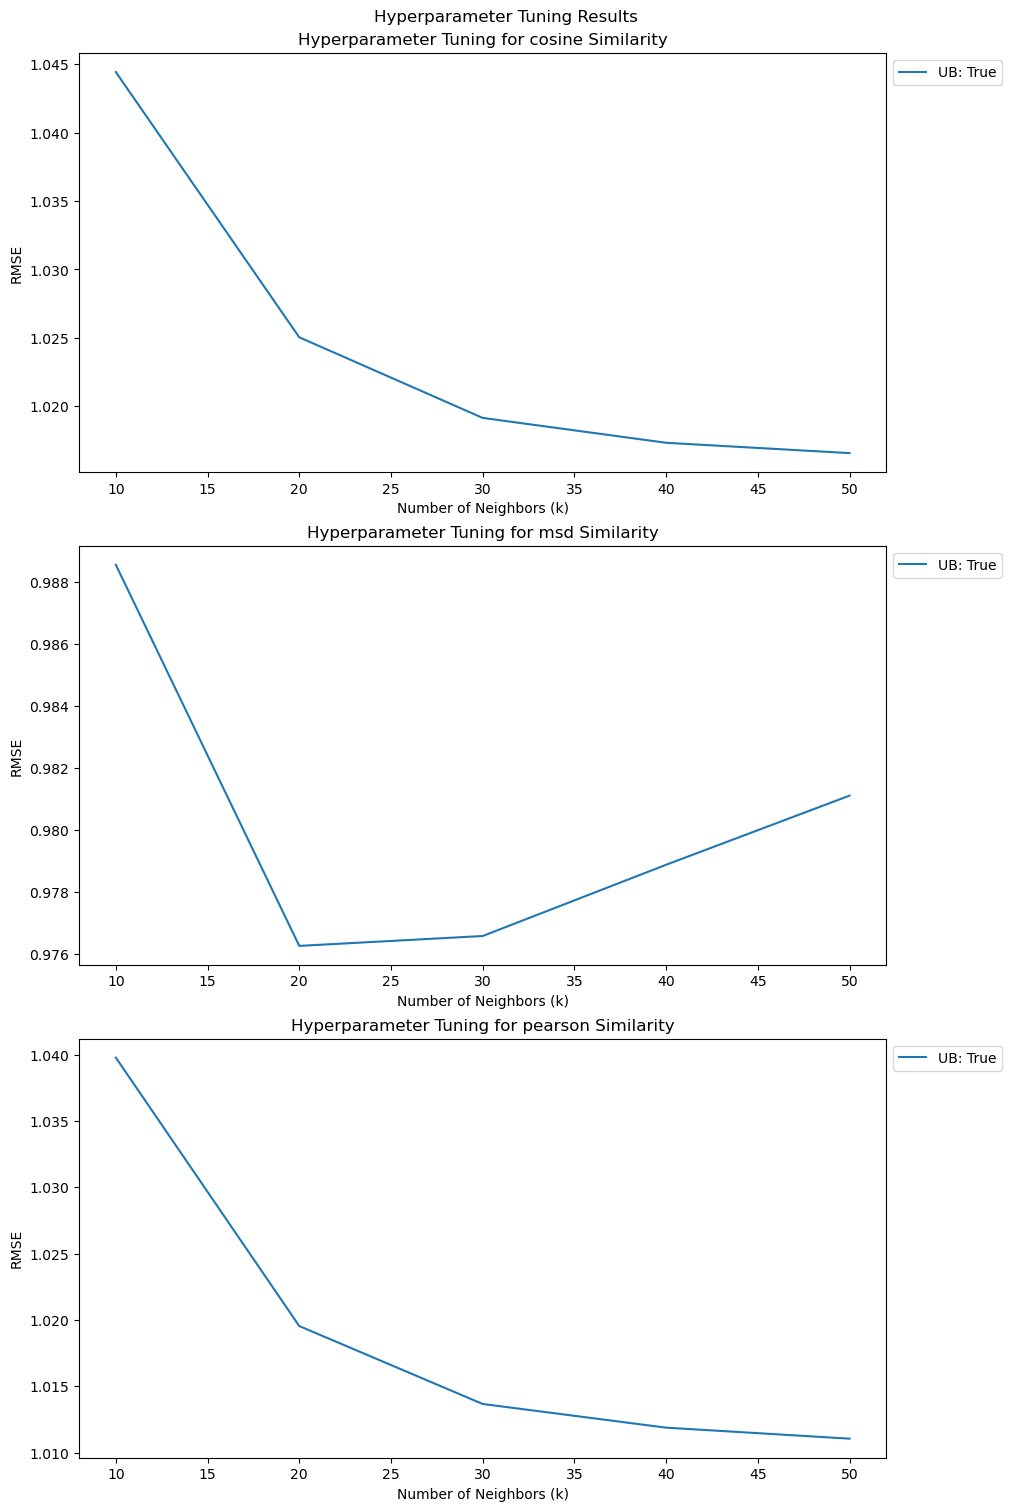

In [26]:
# Pobieranie unikatowych wartości parametrów
unique_metrics = results_df['sim_metric'].unique()
unique_user_based = results_df['user_based'].unique()

# Tworzenie wykresu dla każdej z miar podobieństwa
num_metrics = len(unique_metrics)
fig, axes = plt.subplots(num_metrics, 1, figsize=(10, 5 * num_metrics), constrained_layout=True)

if num_metrics == 1:
    axes = [axes]

for ax, metric in zip(axes, unique_metrics):
    for user_based in unique_user_based:
        filtered = results_df[
            (results_df['sim_metric'] == metric) &
            (results_df['user_based'] == user_based)
        ]

        if filtered.empty:
            print(f"No data for Metric={metric}, User-Based={user_based}")
            continue

        ax.plot(
            filtered['param_k'],
            filtered['mean_test_rmse'],
            label=f"UB: {user_based}"
        )

    ax.set_title(f'Hyperparameter Tuning for {metric} Similarity')
    ax.set_xlabel('Number of Neighbors (k)')
    ax.set_ylabel('RMSE')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.suptitle('Hyperparameter Tuning Results')
plt.savefig("params_tuning.jpg")
plt.show()

In [27]:
print(f"Best params: {gs.best_params['rmse']}")
print(f"Best RMSE: {gs.best_score['rmse']}")

Best params: {'k': 20, 'sim_options': {'name': 'msd', 'user_based': True}}
Best RMSE: 0.9762523230879872


## Zadanie 4. (2,5 pkt)
1. Narysuj analogiczne, co powyżej wykresy dla
*   MAE,
*   czasu.
2. Co możesz powiedzieć o otrzymanych wynikach? Czy któraś konfiguracja jest zawsze optymalna? Którą miarą najlepiej się kierować?


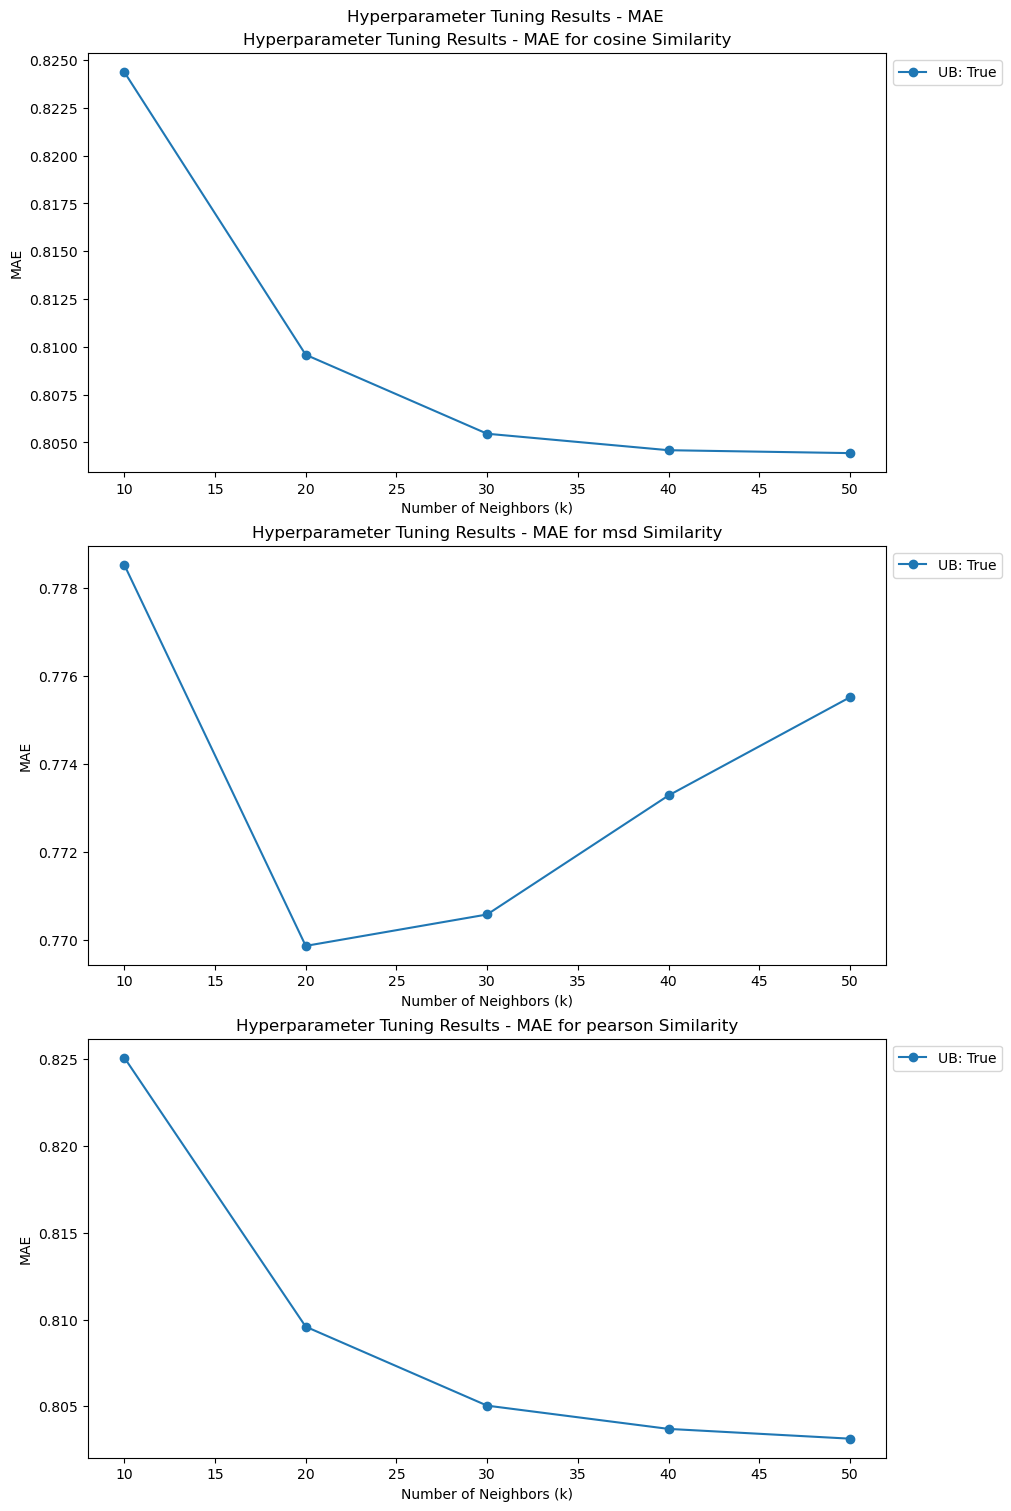

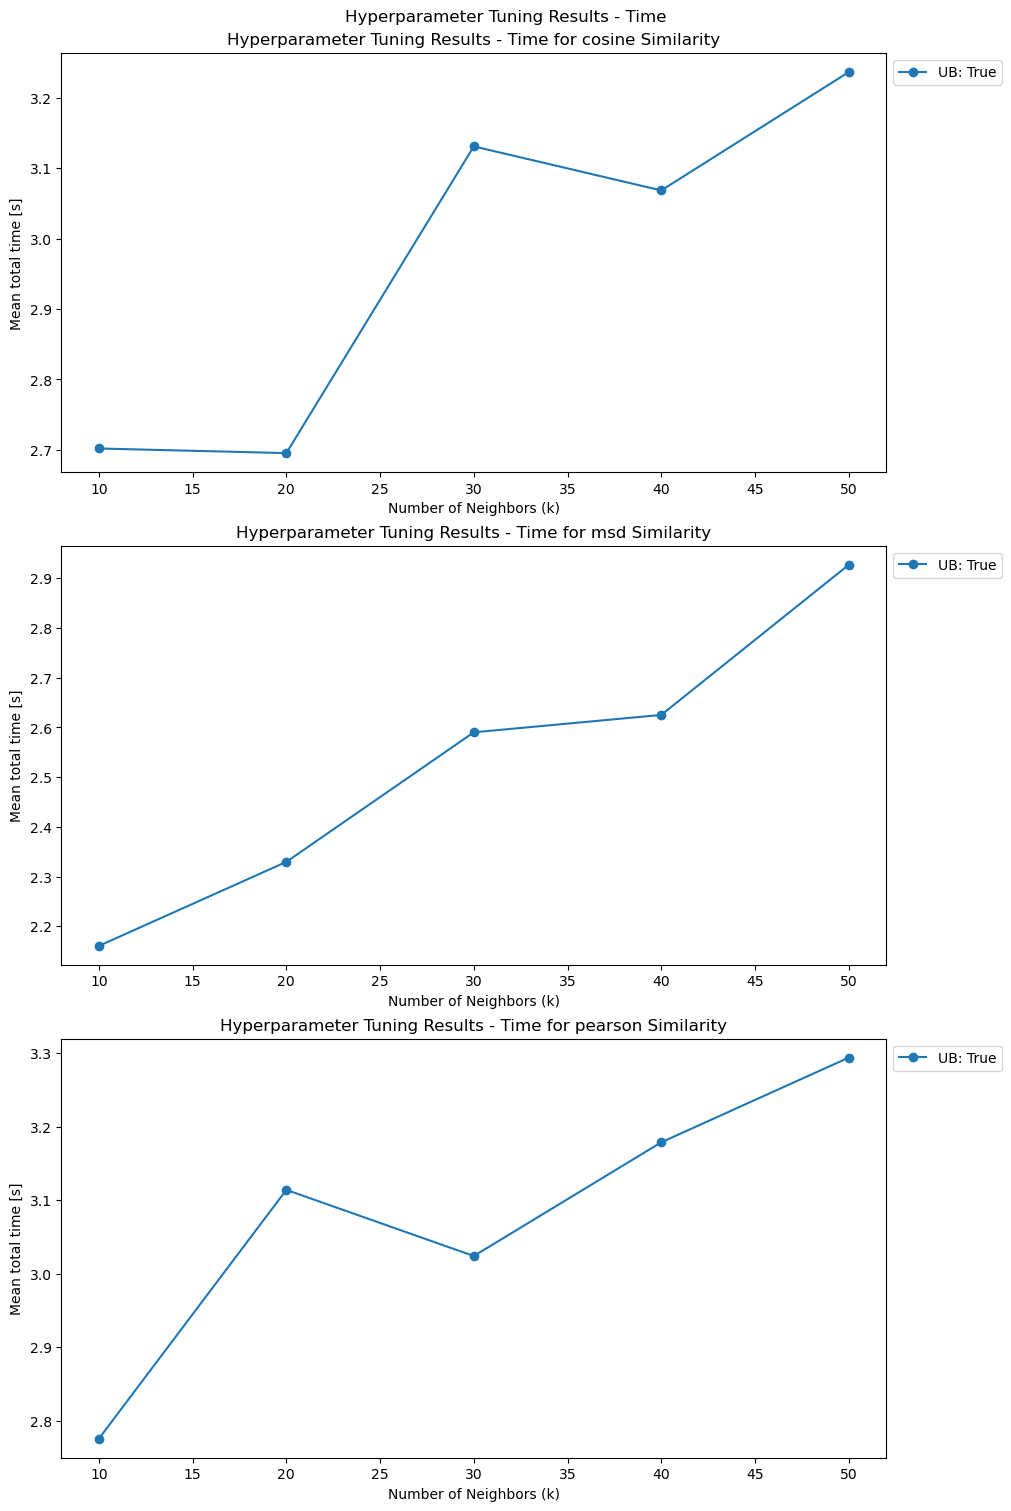

Best params for MAE: {'k': 20, 'sim_options': {'name': 'msd', 'user_based': True}}
Best MAE: 0.7698732986808281


,param_k,sim_metric,user_based,mean_fit_time,mean_test_time,mean_total_time
1,10,msd,True,0.383164,1.777348,2.160512
4,20,msd,True,0.377986,1.951555,2.329542
7,30,msd,True,0.392352,2.197769,2.590121
10,40,msd,True,0.367885,2.257187,2.625072
3,20,cosine,True,0.751283,1.943935,2.695218


In [28]:
from pathlib import Path

Path('plots').mkdir(exist_ok=True)

results_df['mean_total_time'] = results_df['mean_fit_time'] + results_df['mean_test_time']
unique_metrics = results_df['sim_metric'].unique()
unique_user_based = results_df['user_based'].unique()
num_metrics = len(unique_metrics)

def plot_tuning_results(metric_column, ylabel, title, output_file):
    fig, axes = plt.subplots(num_metrics, 1, figsize=(10, 5 * num_metrics), constrained_layout=True)

    if num_metrics == 1:
        axes = [axes]

    for ax, metric in zip(axes, unique_metrics):
        for user_based in unique_user_based:
            filtered = results_df[
                (results_df['sim_metric'] == metric) &
                (results_df['user_based'] == user_based)
            ].sort_values('param_k')

            if filtered.empty:
                print(f"No data for Metric={metric}, User-Based={user_based}")
                continue

            ax.plot(
                filtered['param_k'],
                filtered[metric_column],
                marker='o',
                label=f"UB: {user_based}"
            )

        ax.set_title(f'{title} for {metric} Similarity')
        ax.set_xlabel('Number of Neighbors (k)')
        ax.set_ylabel(ylabel)
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    plt.suptitle(title)
    plt.savefig(output_file)
    plt.show()

plot_tuning_results('mean_test_mae', 'MAE', 'Hyperparameter Tuning Results - MAE', 'plots/mae.png')
plot_tuning_results('mean_total_time', 'Mean total time [s]', 'Hyperparameter Tuning Results - Time', 'plots/time.png')

print(f"Best params for MAE: {gs.best_params['mae']}")
print(f"Best MAE: {gs.best_score['mae']}")

time_columns = ['param_k', 'sim_metric', 'user_based', 'mean_fit_time', 'mean_test_time', 'mean_total_time']
results_df[time_columns].sort_values('mean_total_time').head()

Na podstawie wyników najlepszą konfiguracją pod względem MAE jest **UserKNN** z miarą podobieństwa **msd** oraz `k = 20`. Dla tej konfiguracji MAE wynosi około **0.7699**. Ten sam zestaw parametrów był również najlepszy dla RMSE, więc pod względem jakości predykcji wypada najlepiej spośród sprawdzonych wariantów. Dla miar `cosine` i `pearson` błąd MAE maleje przy większym `k`, ale nawet dla większej liczby sąsiadów pozostaje wyższy niż dla `msd`.

Pod względem czasu najlepsza jest jednak inna konfiguracja: najszybsze było `msd` z `k = 10`, z łącznym czasem około **2.16 s**. Widać też, że czas działania zwykle rośnie wraz z liczbą sąsiadów, szczególnie dla `msd`, chociaż pojedyncze pomiary mogą się lekko wahać. Oznacza to, że nie ma jednej konfiguracji zawsze optymalnej dla wszystkich kryteriów. Jeżeli najważniejsza jest jakość rekomendacji, najlepiej kierować się przede wszystkim RMSE lub MAE. Jeżeli kilka konfiguracji ma podobny błąd, wtedy warto wybrać szybszą z nich.

---



## Zadanie 5 (1,5 pkt)
Znajdź optymalne hiperparametry dla algorytmu ItemKNN względem miar błędu i czasu. Zwizualizuj wyniki analizy na wykresie.

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson si

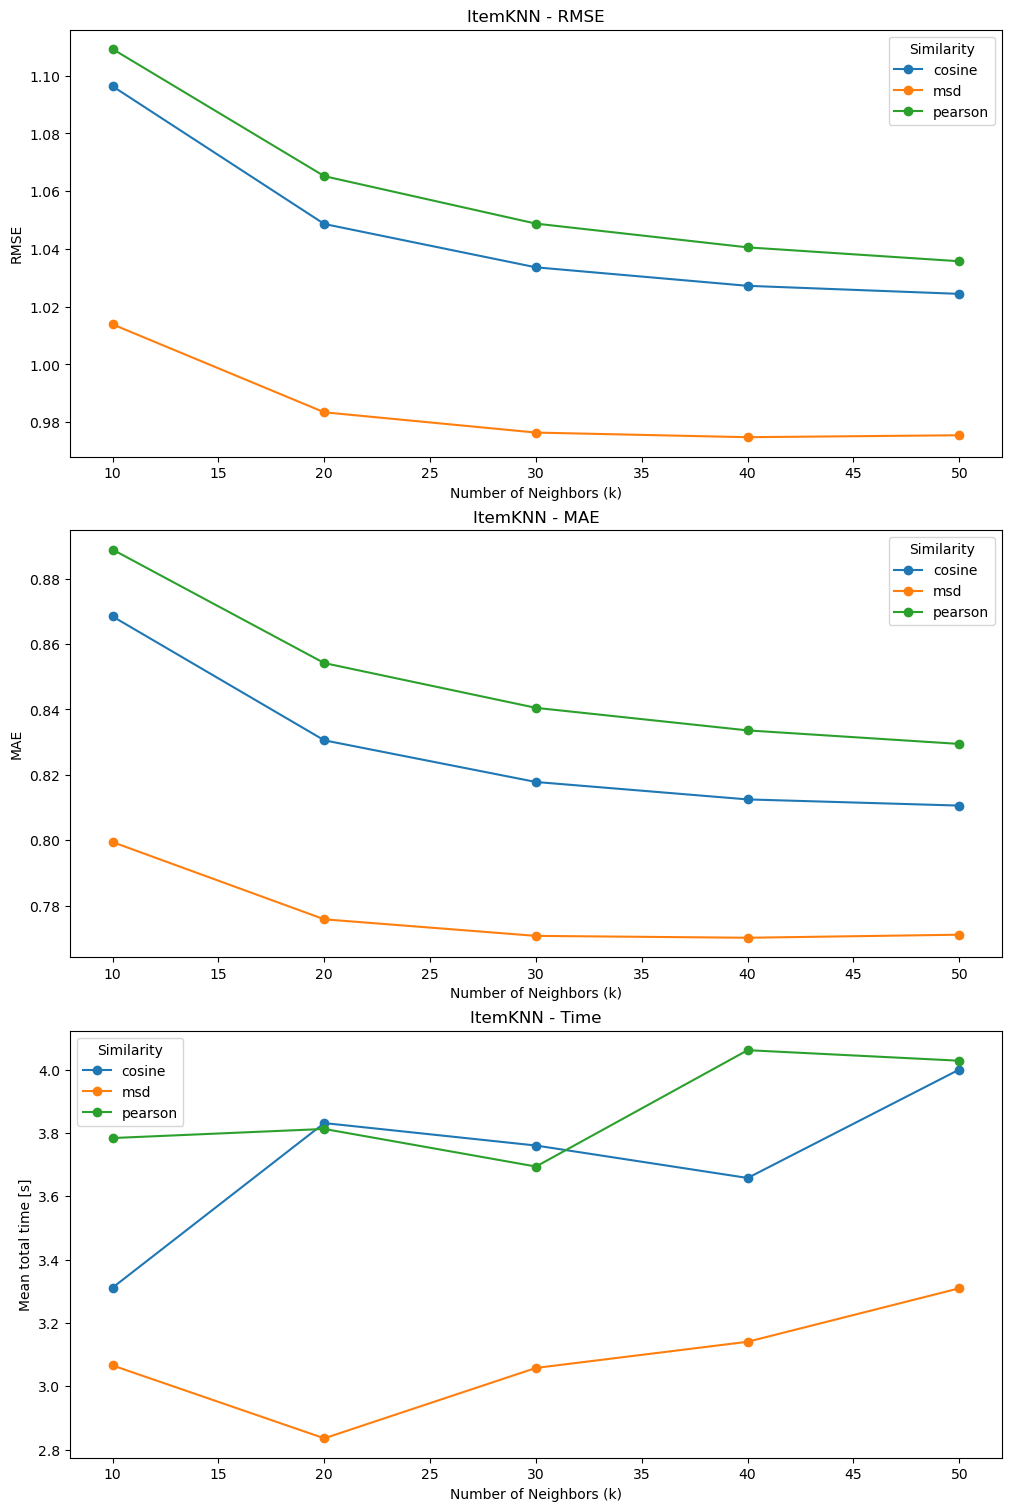

Best ItemKNN params for RMSE: {'k': 40, 'sim_options': {'name': 'msd', 'user_based': False}}
Best ItemKNN RMSE: 0.974753183059909
Best ItemKNN params for MAE: {'k': 40, 'sim_options': {'name': 'msd', 'user_based': False}}
Best ItemKNN MAE: 0.7701916361432966
Fastest ItemKNN configuration:
param_k                  20
sim_metric              msd
mean_fit_time      0.515183
mean_test_time     2.320551
mean_total_time    2.835734
Name: 4, dtype: object


,param_k,sim_metric,mean_test_rmse,mean_test_mae,mean_total_time
10,40,msd,0.974753,0.770192,3.140569
13,50,msd,0.975433,0.771129,3.309407
7,30,msd,0.976355,0.770766,3.057930
4,20,msd,0.983382,0.775833,2.835734
1,10,msd,1.013847,0.799445,3.065726


In [29]:
item_param_grid = {
    'k': [10, 20, 30, 40, 50],
    'sim_options': {
        'name': ['cosine', 'msd', 'pearson'],
        'user_based': [False],
    }
}

item_gs = GridSearchCV(KNNBasic, item_param_grid, measures=['rmse', 'mae'], cv=5)
item_gs.fit(data)

item_results_df = pd.DataFrame(item_gs.cv_results)
item_results_df['sim_metric'] = item_results_df['param_sim_options'].apply(lambda x: x.get('name', None) if isinstance(x, dict) else None)
item_results_df['user_based'] = item_results_df['param_sim_options'].apply(lambda x: x.get('user_based', None) if isinstance(x, dict) else None)
item_results_df['mean_total_time'] = item_results_df['mean_fit_time'] + item_results_df['mean_test_time']

item_unique_metrics = item_results_df['sim_metric'].unique()

fig, axes = plt.subplots(3, 1, figsize=(10, 15), constrained_layout=True)

for metric in item_unique_metrics:
    filtered = item_results_df[item_results_df['sim_metric'] == metric].sort_values('param_k')

    axes[0].plot(filtered['param_k'], filtered['mean_test_rmse'], marker='o', label=metric)
    axes[1].plot(filtered['param_k'], filtered['mean_test_mae'], marker='o', label=metric)
    axes[2].plot(filtered['param_k'], filtered['mean_total_time'], marker='o', label=metric)

axes[0].set_title('ItemKNN - RMSE')
axes[0].set_ylabel('RMSE')
axes[1].set_title('ItemKNN - MAE')
axes[1].set_ylabel('MAE')
axes[2].set_title('ItemKNN - Time')
axes[2].set_ylabel('Mean total time [s]')

for ax in axes:
    ax.set_xlabel('Number of Neighbors (k)')
    ax.legend(title='Similarity')

plt.savefig('item_knn_tuning.jpg')
plt.show()

fastest_item_config = item_results_df.sort_values('mean_total_time').iloc[0]

print(f"Best ItemKNN params for RMSE: {item_gs.best_params['rmse']}")
print(f"Best ItemKNN RMSE: {item_gs.best_score['rmse']}")
print(f"Best ItemKNN params for MAE: {item_gs.best_params['mae']}")
print(f"Best ItemKNN MAE: {item_gs.best_score['mae']}")
print('Fastest ItemKNN configuration:')
print(fastest_item_config[['param_k', 'sim_metric', 'mean_fit_time', 'mean_test_time', 'mean_total_time']])

item_results_df[['param_k', 'sim_metric', 'mean_test_rmse', 'mean_test_mae', 'mean_total_time']].sort_values('mean_test_rmse').head()

## Zadanie 6. (2,5 pkt)
1.   Napisz własną implementację naiwnego algorytmu najwyżej oceniane.
2.   Porównaj wyniki z wyznaczoną wcześniej najlepszą wersją algorytmu kNN. Co możesz powiedzieć o tych wynikach?



In [30]:
class TopRatedAlgorithm(AlgoBase):
    def fit(self, trainset):
        AlgoBase.fit(self, trainset)
        self.item_means = {
            item_inner_id: np.mean([rating for _, rating in ratings])
            for item_inner_id, ratings in trainset.ir.items()
        }
        self.global_mean = trainset.global_mean
        return self

    def estimate(self, user_inner_id, item_inner_id):
        return self.item_means.get(item_inner_id, self.global_mean)


knn_candidates = [
    {
        'algorytm': 'UserKNN',
        'cv_rmse': gs.best_score['rmse'],
        'cv_mae': gs.best_score['mae'],
        'params': gs.best_params['rmse'],
    },
    {
        'algorytm': 'ItemKNN',
        'cv_rmse': item_gs.best_score['rmse'],
        'cv_mae': item_gs.best_score['mae'],
        'params': item_gs.best_params['rmse'],
    },
]

best_knn = min(knn_candidates, key=lambda x: x['cv_rmse'])
best_knn_params = best_knn['params']

algorithms = [
    (
        f"Best kNN ({best_knn['algorytm']})",
        KNNBasic(k=best_knn_params['k'], sim_options=best_knn_params['sim_options'])
    ),
    ('TopRatedAlgorithm', TopRatedAlgorithm()),
]

comparison_results = []

for algo_name, algo in algorithms:
    algo.fit(trainset)
    predictions = algo.test(testset)

    comparison_results.append({
        'algorytm': algo_name,
        'RMSE': accuracy.rmse(predictions, verbose=False),
        'MAE': accuracy.mae(predictions, verbose=False),
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df

Computing the msd similarity matrix...
Done computing similarity matrix.


,algorytm,RMSE,MAE
0,Best kNN (ItemKNN),0.974616,0.771732
1,TopRatedAlgorithm,1.025016,0.819798


Naiwny algorytm `TopRatedAlgorithm` przewiduje ocenę na podstawie średniej oceny danego filmu w zbiorze treningowym. Dzięki temu filmy wysoko oceniane historycznie dostają wysokie predykcje, ale algorytm nie uwzględnia indywidualnych preferencji użytkownika.

W porównaniu za lepszy uznajemy model z niższymi wartościami RMSE i MAE. Najlepszy kNN zwykle powinien osiągać niższe błędy, ponieważ korzysta z podobieństwa użytkowników lub filmów, a więc modeluje więcej informacji niż sama średnia ocena filmu. Jeżeli wyniki obu metod są zbliżone, oznacza to, że prosty algorytm średnich ocen jest mocnym punktem odniesienia, a dodatkowa złożoność kNN daje niewielki zysk. Jeżeli kNN ma wyraźnie niższy błąd, warto go wybrać mimo większego kosztu obliczeniowego.

---

